In [1]:
import os

KAGGLE_API_TOKEN = "KGAT_ba6729699cb9f8627fcd24df9e26db06"

os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/access_token", "w") as f:
    f.write(KAGGLE_API_TOKEN)
os.system("chmod 600 /root/.kaggle/access_token")

!pip install -q -U kaggle
!kaggle competitions list

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.2/126.2 kB 6.0 MB/s eta 0:00:00
ref                                                                           deadline             category         reward  teamCount  userHasEntered  userRank  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  --------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False         0  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False         0  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False         0  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1

In [2]:
os.system("rm -f /content/data-science-bowl-2018.zip")
!kaggle competitions download -c data-science-bowl-2018 -p /content

ZIP_PATH = "/content/data-science-bowl-2018.zip"
size_mb = os.path.getsize(ZIP_PATH) / 1e6
print("downloaded:", ZIP_PATH, "-", round(size_mb, 1), "MB")

100% 358M/358M [00:10<00:00, 36.5MB/s]

downloaded: /content/data-science-bowl-2018.zip - 375.8 MB


In [3]:
import zipfile

with zipfile.ZipFile(ZIP_PATH) as z:
    bad = z.testzip()
    if bad is not None:
        raise RuntimeError("corrupt entry in zip: " + str(bad))
    z.extractall("/content/dsb2018")

print(os.listdir("/content/dsb2018"))

for inner in ["stage1_train.zip", "stage1_test.zip"]:
    inner_path = os.path.join("/content/dsb2018", inner)
    out_dir = "/content/" + inner.replace(".zip", "")
    if os.path.exists(inner_path) and not os.path.exists(out_dir):
        with zipfile.ZipFile(inner_path) as z:
            z.extractall(out_dir)

TRAIN_DIR = "/content/stage1_train"
TEST_DIR = "/content/stage1_test"

print("train images:", len(os.listdir(TRAIN_DIR)))
print("test images:", len(os.listdir(TEST_DIR)))

['stage1_train.zip', 'stage2_sample_submission_final.csv.zip', 'stage1_test.zip', 'stage1_solution.csv.zip', 'stage2_test_final.zip', 'stage1_train_labels.csv.zip', 'stage1_sample_submission.csv.zip']
train images: 670
test images: 65


In [4]:
import glob
import numpy as np
import pandas as pd
import cv2
from PIL import Image
from scipy.ndimage import label

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

In [5]:
def rle_encode(mask):
    pixels = mask.T.flatten()
    pixels = np.concatenate([[0], pixels, [0]])
    runs = np.where(pixels[1:] != pixels[:-1])[0] + 1
    runs[1::2] -= runs[0::2]
    return ' '.join(str(x) for x in runs)

In [6]:
class NucleiDataset(Dataset):
    def __init__(self, root_dir, img_size=(256, 256), is_train=True):
        self.root_dir = root_dir
        self.img_size = img_size
        self.is_train = is_train
        self.image_ids = sorted(
            d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))
        )

    def __len__(self):
        return len(self.image_ids)

    def __getitem__(self, idx):
        img_id = self.image_ids[idx]
        img_folder = os.path.join(self.root_dir, img_id, "images")
        img_path = glob.glob(os.path.join(img_folder, "*.png"))[0]

        image = Image.open(img_path).convert("RGB")
        orig_w, orig_h = image.size

        image = image.resize(self.img_size, Image.BILINEAR)
        image_tensor = TF.to_tensor(image)

        if self.is_train:
            mask_folder = os.path.join(self.root_dir, img_id, "masks")
            mask_paths = glob.glob(os.path.join(mask_folder, "*.png"))

            combined_mask = np.zeros((self.img_size[1], self.img_size[0]), dtype=np.float32)
            for mp in mask_paths:
                m = Image.open(mp).convert("L").resize(self.img_size, Image.NEAREST)
                m_arr = np.array(m) > 0
                combined_mask = np.maximum(combined_mask, m_arr.astype(np.float32))

            mask_tensor = torch.from_numpy(combined_mask).unsqueeze(0)
            return image_tensor, mask_tensor, img_id

        return image_tensor, img_id, orig_h, orig_w

In [7]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.encoder1 = DoubleConv(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2, 2)

        self.encoder2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2, 2)

        self.encoder3 = DoubleConv(128, 256)
        self.pool3 = nn.MaxPool2d(2, 2)

        self.encoder4 = DoubleConv(256, 512)
        self.pool4 = nn.MaxPool2d(2, 2)

        self.bottleneck = DoubleConv(512, 1024)

        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.decoder4 = DoubleConv(1024, 512)

        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.decoder3 = DoubleConv(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.decoder2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.decoder1 = DoubleConv(128, 64)

        self.final_conv = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool1(e1))
        e3 = self.encoder3(self.pool2(e2))
        e4 = self.encoder4(self.pool3(e3))

        b = self.bottleneck(self.pool4(e4))

        d4 = self.decoder4(torch.cat([self.up4(b), e4], dim=1))
        d3 = self.decoder3(torch.cat([self.up3(d4), e3], dim=1))
        d2 = self.decoder2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.decoder1(torch.cat([self.up1(d2), e1], dim=1))

        return self.final_conv(d1)

In [8]:
class BCEDiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super(BCEDiceLoss, self).__init__()
        self.smooth = smooth
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)

        probs = torch.sigmoid(logits)
        probs_flat = probs.view(-1)
        targets_flat = targets.view(-1)

        intersection = (probs_flat * targets_flat).sum()
        dice_score = (2. * intersection + self.smooth) / (probs_flat.sum() + targets_flat.sum() + self.smooth)
        dice_loss = 1.0 - dice_score

        return bce_loss + dice_loss

In [9]:
def train_unet(data_dir, epochs=20, batch_size=16, lr=1e-4, device='cuda', num_workers=2):
    device = torch.device(device) if isinstance(device, str) else device

    dataset = NucleiDataset(root_dir=data_dir, img_size=(256, 256), is_train=True)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)

    model = UNet(in_channels=3, out_channels=1).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = BCEDiceLoss()

    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for images, masks, _ in dataloader:
            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, masks)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)

        epoch_loss = running_loss / len(dataset)
        print(f"Epoch [{epoch + 1}/{epochs}] - Loss: {epoch_loss:.4f}")

    return model


def generate_submission(model, test_dir, output_csv="submission.csv", device='cuda', num_workers=2):
    device = torch.device(device) if isinstance(device, str) else device

    test_dataset = NucleiDataset(root_dir=test_dir, img_size=(256, 256), is_train=False)
    test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=num_workers)

    model.eval()
    results = []

    with torch.no_grad():
        for images, img_ids, orig_h, orig_w in test_loader:
            img_id = img_ids[0]
            images = images.to(device)

            logits = model(images)
            probs = torch.sigmoid(logits).squeeze().cpu().numpy()
            w, h = int(orig_w.item()), int(orig_h.item())
            probs_resized = cv2.resize(probs, (w, h), interpolation=cv2.INTER_LINEAR)
            mask_orig = (probs_resized > 0.5).astype(np.uint8)

            labeled_mask, num_features = label(mask_orig)

            if num_features == 0:
                results.append({"ImageId": img_id, "EncodedPixels": ""})
            else:
                for i in range(1, num_features + 1):
                    instance_mask = (labeled_mask == i).astype(np.uint8)
                    rle = rle_encode(instance_mask)
                    if rle:
                        results.append({"ImageId": img_id, "EncodedPixels": rle})

    sub_df = pd.DataFrame(results)
    sub_df.to_csv(output_csv, index=False)
    print(f"Saved submission file to {output_csv}")

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

trained_model = train_unet(TRAIN_DIR, epochs=20, batch_size=16, device=device)
generate_submission(trained_model, TEST_DIR, output_csv="submission.csv", device=device)

Using device: cuda
Epoch [1/20] - Loss: 1.0416
Epoch [2/20] - Loss: 0.8028
Epoch [3/20] - Loss: 0.7414
Epoch [4/20] - Loss: 0.6799
Epoch [5/20] - Loss: 0.6348
Epoch [6/20] - Loss: 0.6115
Epoch [7/20] - Loss: 0.5721
Epoch [8/20] - Loss: 0.5425
Epoch [9/20] - Loss: 0.5130
Epoch [10/20] - Loss: 0.4846
Epoch [11/20] - Loss: 0.4656
Epoch [12/20] - Loss: 0.4442
Epoch [13/20] - Loss: 0.4272
Epoch [14/20] - Loss: 0.4044
Epoch [15/20] - Loss: 0.3845
Epoch [16/20] - Loss: 0.3680
Epoch [17/20] - Loss: 0.3575
Epoch [18/20] - Loss: 0.3483
Epoch [19/20] - Loss: 0.3294
Epoch [20/20] - Loss: 0.3153
Saved submission file to submission.csv


In [11]:

import matplotlib.pyplot as plt

def visualize_prediction(model, image_id, data_dir, device, threshold=0.5):
    img_folder = os.path.join(data_dir, image_id, "images")
    img_path = glob.glob(os.path.join(img_folder, "*.png"))[0]
    image = Image.open(img_path).convert("RGB")
    orig_w, orig_h = image.size

    image_resized = image.resize((256, 256), Image.BILINEAR)
    image_tensor = TF.to_tensor(image_resized).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        logits = model(image_tensor)
        probs = torch.sigmoid(logits).squeeze().cpu().numpy()

    probs_resized = cv2.resize(probs, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
    mask = (probs_resized > threshold).astype(np.uint8)

    labeled_mask, num_features = label(mask)

    overlay = np.array(image).copy()
    for i in range(1, num_features + 1):
        inst = (labeled_mask == i).astype(np.uint8)
        contours, _ = cv2.findContours(inst, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(overlay, contours, -1, (255, 0, 0), 2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(image)
    axes[0].set_title(image_id[:12] + " - original")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title(str(num_features) + " nuclei detected")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    axes[2].set_title("overlay")
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    return num_features

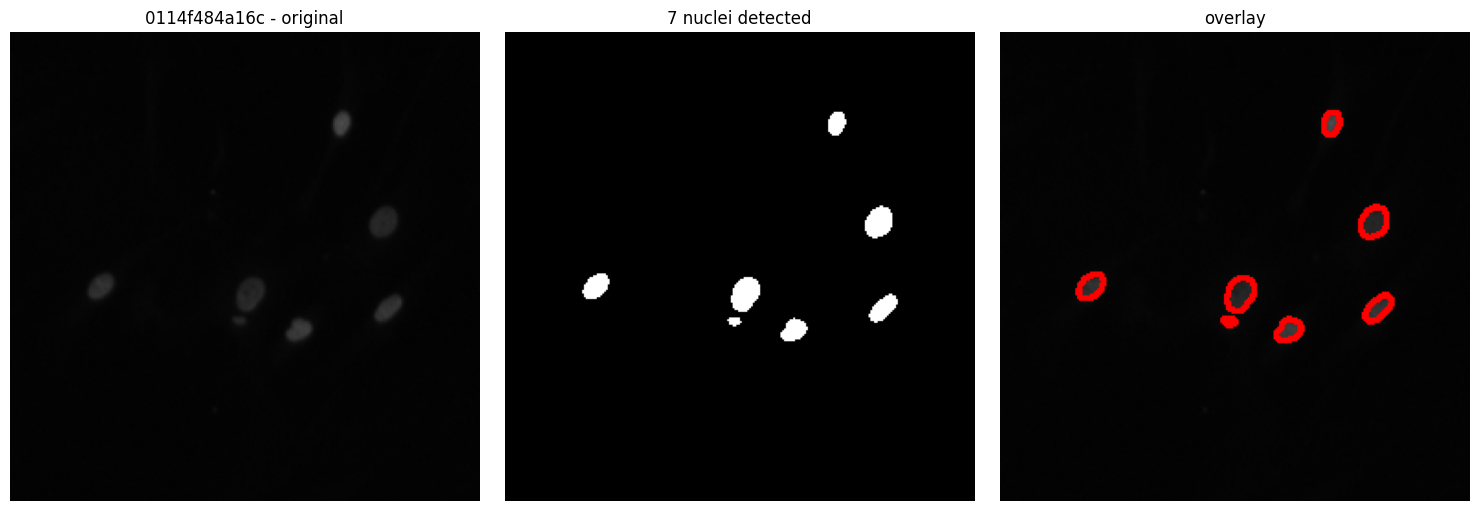

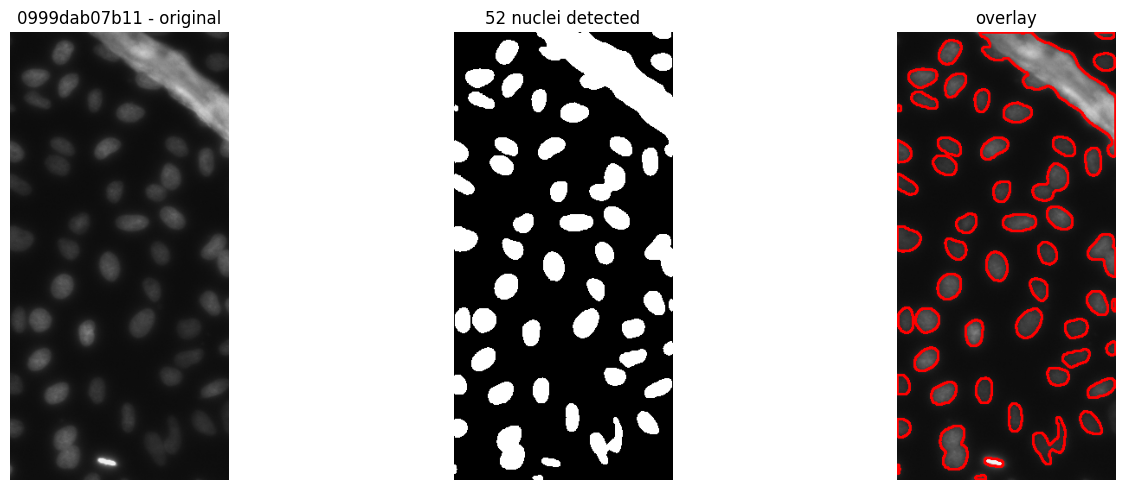

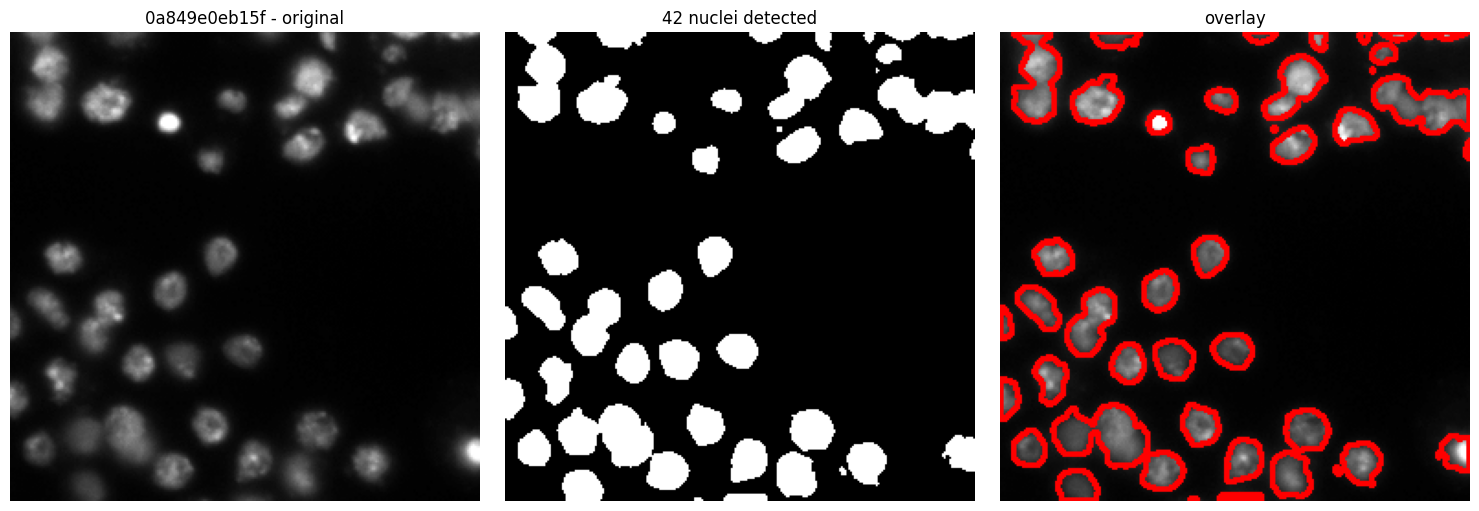

In [12]:

test_ids = sorted(os.listdir(TEST_DIR))
for tid in test_ids[:3]:
    visualize_prediction(trained_model, tid, TEST_DIR, device)